### Imports and Setup

In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
import concurrent

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve
from scipy.optimize import minimize
from PIL import Image
import pandas as pd

from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassifyUncertain
from whale_gunshot_localization.datasets.dataloaders import get_dataloaders_range_classify_eval_loc, get_exp_data_dataloader_range_classify
from whale_gunshot_localization.utils.transformations import get_image_transform_range_classify, to_spect

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config

Using the GPU!


Settings for synthetic data evaluation

In [2]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [3]:
dl = get_dataloaders_range_classify_eval_loc(splits=['val', 'test'],
                                        batch_size=128,
                                        transform=get_image_transform_range_classify(),
                                        squeeze=True,
                                        num_workers=20)

Load the desired model

In [4]:
model = TCNRangeAndClassifyUncertain(input_size=dl[split].dataset.size[0], 
                                     num_channels=7*[368],
                                     kernel_size=6,
                                     dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/range_classify_uncertain', 'weights_best.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

## Evaluate Model On Synthetic Data
Get predictions and labels

In [5]:
def evaluate_model(model, dataloader):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    r_p : array-like
        list of predicted ranges
    r_t : array-like
        list of true ranges
    c_p : array-like
        list of predicted classes
    c_t : array-like
        list of true classes
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # get number of TOSSITs
    num_TOSSITs = dataloader.dataset.num_TOSSITs
    
    # get scale
    max_r = config['scaling']['max_r']
    
    # initialize arrays for results
    r_t, r_p, r_std, c_t, c_p, c_std, outputs_all = [[[] for _ in range(num_TOSSITs)] for _ in range(7)]
    x_t, y_t = [], []
    
    for inputs, target_c, target_r, target_x, target_y in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        target_c = target_c.to(device)
        target_r = target_r.to(device)
        target_x = target_x.to(device)
        target_y = target_y.to(device)
                        
        with torch.set_grad_enabled(False):
            
            for t in range(num_TOSSITs):
                
                # get outputs for a given TOSSIT
                outputs = model(inputs[:,t,...])

                outputs_all[t] += outputs.detach().tolist()

                # store x predictions and labels
                r_p[t] += (outputs[:,0] * max_r).detach().tolist()
                r_t[t] += (target_r[:,t]).detach().tolist()
                r_std[t] += (torch.exp(outputs[:,1]) * max_r).detach().tolist()


                # store y predictions and labels
                c_p[t] += (F.softmax(outputs[:,2:4].detach(),dim=1)[:,1] >= 0.5).tolist()
                c_t[t] += target_c.squeeze().detach().tolist()
                c_std[t] += (torch.exp(outputs[:,4])).detach().tolist()
                
            # store locations
            x_t += target_x.detach().tolist()
            y_t += target_y.detach().tolist()
    
    return np.asarray(r_p).T, np.asarray(r_t).T, np.asarray(r_std).T, np.asarray(c_p).T, np.asarray(c_t).T, np.asarray(c_std).T, np.asarray(x_t), np.asarray(y_t), np.transpose(np.asarray(outputs_all), (1, 0, 2))

In [6]:
r_p, r_t, r_std, c_p, c_t, c_std, x_t, y_t, outputs_all = evaluate_model(model, dl[split])

  0%|          | 0/429 [00:00<?, ?it/s]

In [7]:
acc = accuracy_score(c_t.flatten(), c_p.flatten())
prec = precision_score(c_t.flatten(), c_p.flatten())
recall = recall_score(c_t.flatten(), c_p.flatten())

print("statistics")
print("-------------------")
print(f'Accuracy: {np.around(acc, 5)}')
print(f'Precision: {np.around(prec, 5)}')
print(f'Recall: {np.around(recall, 5)}')

statistics
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [8]:
acc = accuracy_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)
prec = precision_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)
recall = recall_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)

print("statistics")
print("-------------------")
print(f'Accuracy: {np.around(acc, 5)}')
print(f'Precision: {np.around(prec, 5)}')
print(f'Recall: {np.around(recall, 5)}')

statistics
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [59]:
def localize(r_p, r_std, c_p, c_t):
       
    # get locations of TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # to store locations
    locs = np.zeros((r_p.shape[0], 2))
    
    # iterate through experimental call sets
    for i in tqdm(range(r_p.shape[0])):
        
        ones = np.where((c_p[i] == 1) & (c_t[i] == 1))[0]
        
        if len(ones) >= 3:
            def obj(x):
                # calculate l2s between TOSSIT positions and predicted location
                l2 = np.sqrt((TOSSIT_locations[ones,0] - x[0]) ** 2 + (TOSSIT_locations[ones,1] - x[1]) ** 2)

                # return sum squared error between l2s and predicted ranges
                return np.sum((l2.squeeze() - r_p[i,ones].squeeze()) ** 2)

            # minimize
            res = minimize(obj, [0, 0], method='Nelder-Mead', options={'disp': False})

            # extract results
            if len(res.x.shape) == 1:
                x = np.expand_dims(res.x, axis=0)
            else:
                x = res.x

            # store results
            locs[i,:] = x
        else:
            locs[i,:] = -1
            continue
        
    return locs

In [60]:
locs = localize(r_p, r_std, c_p, c_t)

  0%|          | 0/54880 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

In [66]:
def plot_regressions(r_t, r_p, c_t, c_p, locs, x_t, y_t, dataloader=None, valid=True):
    """
    Plot regression results.
    
    Parameters
    ----------
    r_t : array-like
        list of true ranges
    r_p : array-like
        list of predicted ranges
    c_t : array-like
        list of true classes
    c_p : array-like
        list of predicted classes
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce r_t, r_p, c_t, c_p
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """
    
    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"

        # make sure dataloader is for simulated data
        assert 'Sim' in type(dataloader.dataset).__name__, "'valid' flag only for simulated data."
        
        # get data, labels, and indices of split
        dataset = dataloader.dataset.data
        labels = dataloader.dataset.labels[:]
        idx = dataloader.batch_sampler.idx
        valid_labels = labels[idx,5].astype(int)
        r_t = r_t[valid_labels==1,:]
        r_p = r_p[valid_labels==1,:]
        x_t = x_t[valid_labels==1]
        y_t = y_t[valid_labels==1]
        locs = locs[valid_labels==1,:]
    
    
    ones = np.where(((c_t + c_p) == 2).sum(axis=1) >= 3)[0]
    r_t = r_t[ones]
    r_p = r_p[ones]
    x_t = x_t[ones]
    y_t = y_t[ones]
    locs = locs[ones,:]
    
    # convert to km
    r_t = r_t / 1000
    r_p = r_p / 1000
    x_t = x_t / 1000
    y_t = y_t / 1000
    locs = locs / 1000
    
    # get endpoints for identity line
    r_mm = (np.min(r_t.flatten()), np.max(r_t.flatten()))
    x_mm = (np.min(x_t), np.max(x_t))
    y_mm = (np.min(y_t), np.max(y_t))
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3)
    f.set_figheight(4)
    f.set_figwidth(15)
    
    # X component
    ax1.plot(x_t, locs[:,1], 'bo', markersize=2, label="predictions")
    ax1.plot([x_mm[0], x_mm[1]], [x_mm[0], x_mm[1]], 'r--', label="identity line")
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("True X Component [km]")
    ax1.set_ylabel("Predicted Distance [km]")
    
    # Y component
    ax2.plot(y_t, locs[:,0], 'bo', markersize=2, label="predictions")
    ax2.plot([y_mm[0], y_mm[1]], [y_mm[0], y_mm[1]], 'r--', label="identity line")
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("True Y Component [km]")
    
    # rough range
    ax3.plot(r_t.flatten(), r_p.flatten(), 'bo', markersize=2, label="predictions")
    ax3.plot([r_mm[0], r_mm[1]], [r_mm[0], r_mm[1]], 'r--', label="identity line")
    ax3.legend()
    ax3.grid()
    ax3.set_xlabel("True Rough Range [km]")
    
    distances = np.sqrt((x_t.squeeze() - locs[:,1]) ** 2 + (y_t.squeeze() - locs[:,0]) ** 2)
    
    plt.figure()
    plt.grid(zorder=3)
    plt.hist(distances, bins='auto', edgecolor='black', zorder=4)
    plt.xlabel("Distance Between Predicted and Ground Truth Location [km]")
    plt.ylabel("Number of Examples")
    
    # calculate component errors
    MSE_X = ((x_t.squeeze() - locs[:,1]) ** 2).mean()
    MSE_Y = ((y_t.squeeze() - locs[:,0]) ** 2).mean()
    MSE_R = ((r_t.flatten() - r_p.flatten()) ** 2).mean()
    
    print("statistics")
    print("-------------------")
    print("MSE (X): {:.3f} km^2".format(MSE_X))
    print("RMSE (X): {:.3f} km".format(np.sqrt(MSE_X)))
    print("-------------------")
    print("MSE (Y): {:.3f} km^2".format(MSE_Y))
    print("RMSE (Y): {:.3f} km".format(np.sqrt(MSE_Y)))
    print("-------------------")
    print("MSE (R): {:.3f} km^2".format(MSE_R))
    print("RMSE (R): {:.3f} km".format(np.sqrt(MSE_R)))
    print("-------------------")

statistics
-------------------
MSE (X): 1.330 km^2
RMSE (X): 1.153 km
-------------------
MSE (Y): 0.354 km^2
RMSE (Y): 0.595 km
-------------------
MSE (R): 0.304 km^2
RMSE (R): 0.552 km
-------------------


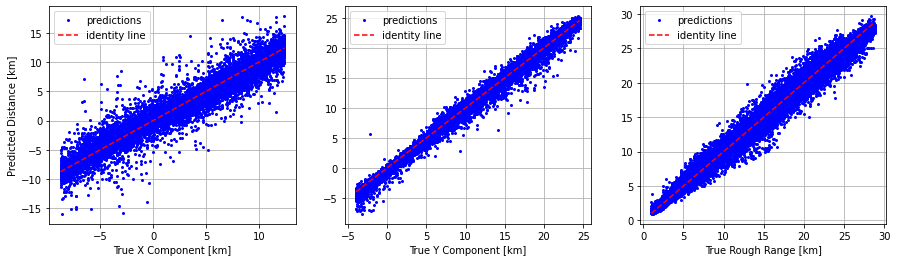

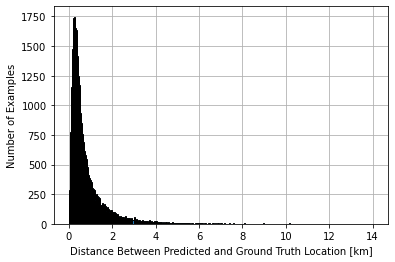

In [67]:
plot_regressions(r_t, r_p, c_t, c_p, locs, x_t, y_t, dl[split], valid=True)

### Display High Error Calls

In [64]:
def plot_top_k_error(x_t, y_t, locs, c_t, c_p, dataloader, k=5, highest=True, valid=True, plot_predicted=False):
    """
    Plot top/bottom-k error calls.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    k : int
        number of top/bottom error calls to plot
    highest : bool
        whether to plot the highest/lowest error calls
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    plot_predicted : bool
        whether or not to plot the predicted or group truth gunshot locations
    """
    
    x_p = locs[:,[1]]
    y_p = locs[:,[0]]
    
    # get data, labels, and indices of split
    dataset = dataloader.dataset.data
    labels = dataloader.dataset.labels[:]
    
    if 'Sim' in type(dataloader.dataset).__name__:
        idx = dataloader.batch_sampler.idx
    else:
        idx = np.arange(dataset.shape[0])
        
    assert len(idx) >= k, "k must be <= the number of exampes in the dataset"
    
    # get valid examples only
    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"
        
        # make sure dataloader is for simulated data
        assert 'Sim' in type(dataloader.dataset).__name__, "'valid' flag only for simulated data."
        
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels == 1,:]
        x_p = x_p[valid_labels == 1,:]
        y_t = y_t[valid_labels == 1,:]
        y_p = y_p[valid_labels == 1,:]
        idx = idx[valid_labels == 1]
        
    ones = np.where(((c_t + c_p) == 2).sum(axis=1) >= 3)[0]
    x_t = x_t[ones]
    x_p = x_p[ones]
    y_t = y_t[ones]
    y_p = y_p[ones]
    idx = idx[ones]
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    # initialize dataframe
    df = pd.DataFrame(columns=["GT-P Distance [m]", 
                               "Y-Component GT [m]",
                               "Y-Component P [m]",
                               "Y-Component Abs. Error [m]",
                               "X-Component GT [m]",  
                               "X-Component P [m]",
                               "X-Component Abs. Error [m]"])
    
    x_list, y_list = [], []
    for d in range(k):
        
        # store coordinates
        top_k_X = dataset[idx[inds[d]],...]
        if plot_predicted:
            x_list.append(x_p[inds[d]])
            y_list.append(y_p[inds[d]])
        else:
            x_list.append(labels[idx[inds[d]],1])
            y_list.append(labels[idx[inds[d]],0])
        
        # append row to dataframe
        df_row = pd.DataFrame({"GT-P Distance [m]": [np.around(top_k_abs_err[inds[d]][0], 2)],
                               "Y-Component GT [m]": [np.around(y_t[inds[d]].squeeze(), 2)],
                               "Y-Component P [m]": [np.around(y_p[inds[d]].squeeze(), 2)],
                               "Y-Component Abs. Error [m]": [np.around(np.abs(y_t[inds[d]].squeeze() - y_p[inds[d]].squeeze()), 2)],
                               "X-Component GT [m]": [np.around(x_t[inds[d]].squeeze(), 2)],
                               "X-Component P [m]": [np.around(x_p[inds[d]].squeeze(), 2)],
                               "X-Component Abs. Error [m]": [np.around(np.abs(x_t[inds[d]].squeeze() - x_p[inds[d]].squeeze()), 2)]})
        df = pd.concat([df, df_row], ignore_index=True)
        
        # only plot signals if fewer than 20 calls
        if k < 20:
            plt.figure()
            for t in range(num_TOSSITs):
                spect = to_spect(top_k_X[t])
                plt.subplot(1,num_TOSSITs, t+1)
                plt.imshow(spect.squeeze())
                plt.title(f"TOSSIT {t+1}")
                plt.axis('off')
            plt.tight_layout()
    
    # show dataframe tail if less than 20 signals
    if k < 20:
        display(df)
    else:
        display(df.head())
    
    # get correct location label for plot
    loc_label = 'predicted' if plot_predicted else 'ground truth' 
    
    # overlay points onto map
    plt.figure()
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(x_list, y_list, c='#0307fc', s=2, label=loc_label)
    plt.scatter(np.asarray(config['TOSSIT']['TOSSIT_x']), np.asarray(config['TOSSIT']['TOSSIT_y']), s=30, marker='x', label='TOSSIT')
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.legend(loc='lower left')
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")

In [14]:
def plot_top_k_error(r_t, r_p, c_t, c_p, dataloader, k=5, highest=True, valid=True):
    """
    Plot top/bottom-k error calls.
    
    Parameters
    ----------
    r_t : array-like
        list of true ranges
    r_p : array-like
        list of predicted ranges
    c_t : array-like
        list of true classes
    c_p : array-like
        list of predicted classes
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    k : int
        number of top/bottom error calls to plot
    highest : bool
        whether to plot the highest/lowest error calls
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """
    
    # get data, labels, and indices of split
    dataset = dataloader.dataset.data
    labels = dataloader.dataset.labels[:]
    idx = dataloader.batch_sampler.idx
    TOSSIT_LUT = dataloader.dataset.TOSSIT_LUT
    
    assert len(idx) >= k, "k must be <= the number of exampes in the dataset"
    
    # get valid examples only
    if valid:   
        valid_labels = labels[idx,5].astype(int)
        r_t = r_t[valid_labels == 1,:]
        r_p = r_p[valid_labels == 1,:]
        idx = idx[valid_labels == 1]
    
    # filter to true positives
    r_t = r_t[np.where((c_t.squeeze() == 1) & (c_p.squeeze() == 1))[0]]
    r_p = r_p[np.where((c_t.squeeze() == 1) & (c_p.squeeze() == 1))[0]]
    idx = idx[np.where((c_t.squeeze() == 1) & (c_p.squeeze() == 1))[0]]
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = np.abs(r_t - r_p)
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    # initialize dataframe
    df = pd.DataFrame(columns=["Range GT [m]",
                               "Range P [m]",
                               "Range Abs. Error [m]"])
    
    for d in range(k):
        
        # store coordinates
        top_k_X = dataset[idx[inds[d]],TOSSIT_LUT[idx[inds[d]]],...]
        
        # append row to dataframe
        df_row = pd.DataFrame({"Range GT [m]": [np.around(r_t[inds[d]].squeeze(), 2)],
                               "Range P [m]": [np.around(r_p[inds[d]].squeeze(), 2)],
                               "Range Abs. Error [m]": [np.around(np.abs(r_t[inds[d]].squeeze() - r_p[inds[d]].squeeze()), 2)],})
        df = pd.concat([df, df_row], ignore_index=True)
        
        # only plot signals if fewer than 20 calls
        if k < 20:
            plt.figure()
            spect = to_spect(top_k_X)
            plt.imshow(spect.squeeze())
            plt.axis('off')
            plt.tight_layout()
    
    # show dataframe tail if less than 20 signals
    if k < 20:
        display(df)
    else:
        display(df.head())
        display(df.tail())

,GT-P Distance [m],Y-Component GT [m],Y-Component P [m],Y-Component Abs. Error [m],X-Component GT [m],X-Component P [m],X-Component Abs. Error [m]
0,14026.40,20385.67,16187.13,4198.54,-621.50,-14004.78,13383.28
1,13714.97,23906.83,19439.58,4467.26,-2832.69,-15799.73,12967.04
2,13648.46,21775.60,22210.29,434.69,-6492.51,7149.02,13641.54
3,12393.99,21682.94,15516.38,6166.56,6561.50,17312.53,10751.03


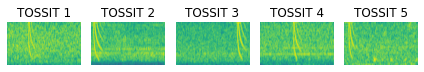

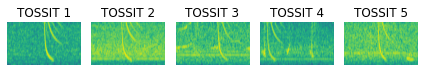

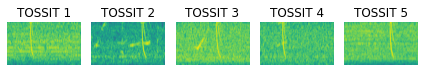

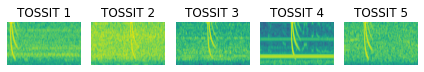

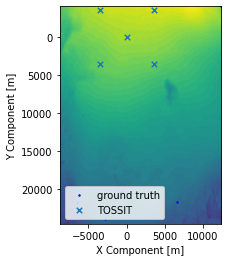

In [65]:
plot_top_k_error(x_t, 
                 y_t,
                 locs,
                 c_t, 
                 c_p,
                 dl[split],
                 highest=True,
                 k=4,
                 valid=True)

## Evaluation Model On Experimental Data

run the network on all isolated experimental examples from all TOSSITs

In [6]:
num_TOSSITs = dl[split].dataset.num_TOSSITs
r_p_all, r_t_all, r_std_all, c_p_all, c_t_all, c_std_all, outputs_all_all = [], [], [], [], [], [], []

for t in range(1, num_TOSSITs+1):
    dl_exp = get_exp_data_dataloader_range_classify(batch_size=128, 
                                                    transform=get_image_transform_range_classify(), 
                                                    squeeze=True,
                                                    TOSSIT=t)

    r_p, r_t, r_std, c_p, c_t, c_std, outputs_all = evaluate_model(model, dl_exp)
    
    r_p_all.append(r_p.squeeze(axis=1))
    r_t_all.append(r_t)
    r_std_all.append(r_std.squeeze(axis=1))
    c_p_all.append(c_p.squeeze(axis=1))
    c_t_all.append(c_t.squeeze(axis=1))
    c_std_all.append(c_std.squeeze(axis=1))
    outputs_all_all.append(outputs_all)
    
r_p_all = np.asarray(r_p_all).T
r_t_all = np.asarray(r_t_all).T
r_std_all = np.asarray(r_std_all).T
c_p_all = np.asarray(c_p_all).T
c_t_all = np.asarray(c_t_all).T
c_std_all = np.asarray(c_std_all).T
outputs_all_all = np.transpose(np.asarray(outputs_all_all), axes=(1, 0, 2))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
def localize(r_p_all, r_std_all, x_buffer=6000, y_buffer=6000, draw_circles=False):
    
    # get locations of TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # to store locations
    locs = np.zeros((r_p_all.shape[0], 2))
    
    ns = 4
    
    # iterate through experimental call sets
    for i in range(r_p_all.shape[0]):
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((TOSSIT_locations[:,0] - x[0]) ** 2 + (TOSSIT_locations[:,1] - x[1]) ** 2)
            
            # return sum squared error between l2s and predicted ranges
            return np.sum((1/(r_std_all.squeeze()[:ns] ** 2))*(l2.squeeze()[:ns] - r_p_all[i].squeeze()[:ns]) ** 2)
        
        # minimize
        res = minimize(obj, [0, 0], method='Nelder-Mead', options={'disp': True})
        
        # extract results
        if len(res.x.shape) == 1:
            x = np.expand_dims(res.x, axis=0)
        else:
            x = res.x
        
        # store results
        locs[i,:] = x
    
    # plot results
    fig = plt.figure()
    plt.ylim([config['scaling']['min_y'] - y_buffer, config['scaling']['max_y'] + y_buffer])
    plt.xlim([config['scaling']['min_x'] - x_buffer, config['scaling']['max_x'] + x_buffer])
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(locs[:,1], locs[:,0], c='#0307fc', s=2, label='predicted location')
    plt.scatter(np.asarray(config['TOSSIT']['TOSSIT_x']), np.asarray(config['TOSSIT']['TOSSIT_y']), s=30, marker='x', label='TOSSIT')
    if draw_circles:
        for t in range(ns):
            c = plt.Circle((TOSSIT_locations[t][1], TOSSIT_locations[t][0]), r_p_all[:,t], fill=False)
            plt.gca().add_artist(c)
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.legend(loc='lower left')
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")
    
    return locs

Optimization terminated successfully.
         Current function value: 4.705783
         Iterations: 125
         Function evaluations: 238


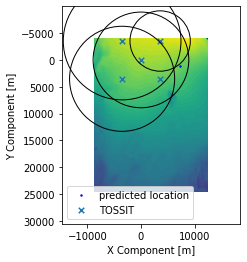

In [69]:
locs = localize(r_p_all, r_std_all, draw_circles=True)